<a href="https://colab.research.google.com/github/suddalaharshini3687/literacy_education_analysis/blob/main/%5B16012573710%5D%2C%5B160125737055%5D%2CCEP_50%2CLiteracy_rate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
# Analyze Literacy Rates and Educational Enrollments by State and Gender

#**Problem Statement:** Analyze literacy rates and educational enrollments by state and gender.

#**Project ID:** CEP-50

#**Roll Nos:** 160125737010,160125737055

#**Names:** Chipuri Sandhya Yadav , Harshini Suddala

#**Department:** Information Technology

#**Institution:** Chaitanya Bharathi Institute of Technology, Hyderabad

## Problem Overview

#This project analyzes literacy rates and educational enrollment data across
#different states and regions of India. The analysis focuses on calculating
#average literacy rates, filtering literacy data by gender, handling missing
#enrollment values, studying literacy and enrollment across age groups and
#regions, and visualizing gender-wise literacy rates.

#Pandas and NumPy are used for data processing and numerical analysis.
#Matplotlib and Seaborn are used for visualization.

## Dataset

#The dataset is obtained from the Government of India Open Government Data
#Platform.

#[Dataset Link](https://data.gov.in/resources/literacy-statistics-india)

## Environment

#**Python Version:** Python 3

#**Libraries Used:**
#- NumPy – numerical calculations
#- Pandas – data loading and data manipulation
#- Matplotlib – data visualization
#- Seaborn – statistical visualization


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the datasets
literacy = pd.read_excel("/content/Table29.6-States.xls")
enrollment = pd.read_csv("/content/UDISE_2021_22_Table_5.17_2.csv.xls")

# Cleaning column names
literacy.columns = literacy.columns.str.strip()
enrollment.columns = enrollment.columns.str.strip()

print("Datasets loaded successfully.")

print("\nLiteracy Data:")
print(literacy.head())

print("\nEnrollment Data:")
print(enrollment.head())

Datasets loaded successfully.

Literacy Data:
  All India/State/Union Territory  1991 - Male  1991 - Female  1991 - Persons  \
0                       All India           52             64              39   
1                  Andhra Pradesh           44             55              33   
2               Arunachal Pradesh           42             52              30   
3                           Assam           53             62              43   
4                           Bihar           38             51              22   

   2001 - Male  2001 - Female  2001 - Persons  2011 - Rural - Male  \
0           65             75              54                   77   
1           61             70              50                   69   
2           54             64              44                   67   
3           63             71              55                   75   
4           47             60              33                   70   

   2011 - Rural - Female  2011 - Rural - Perso

In [62]:
# ## Q1: Calculate average literacy rate (Bloom's Level: 3)

# ### Logic

# The 2011 rural and urban person literacy rates are selected because
# they represent literacy rates without separating male and female.
# The average literacy rate is calculated using Pandas mean().

# ### Functions and Attributes Used

# mean()
# - Syntax: data.mean()
# - Calculates the arithmetic average.

# DataFrame[]
# - Syntax: data[["column1", "column2"]]
# - Selects required columns from a DataFrame.

# Q1: Calculate average literacy rate

# Rural and Urban person literacy rates are used
# because they represent literacy without separating gender.

literacy["2011_Average"] = literacy[
    ["2011 - Rural - Person", "2011 - Urban - Persons"]
].mean(axis=1)

average_literacy = literacy["2011_Average"].mean()

print("Q1: Average Literacy Rate")
print("Average Literacy Rate =", round(average_literacy, 2), "%")

Q1: Average Literacy Rate
Average Literacy Rate = 79.94 %


In [61]:
## Q2: Filter data by gender (Bloom's Level: 3)

### Logic

#The literacy dataset contains separate columns for male and female
#literacy rates. The required male and female columns are filtered
#from the DataFrame to compare literacy rates by gender.

### Functions and Attributes Used

#**DataFrame[]**
#- Used to select specific columns.

#**head()**
#- Syntax: `data.head()`
#- Displays the first five rows of the DataFrame.

# Q2: Filter data by gender

# Male literacy data
male_data = literacy[
    [
        "All India/State/Union Territory",
        "2011 - Rural - Male",
        "2011 - Urban - Male"
    ]
]

# Female literacy data
female_data = literacy[
    [
        "All India/State/Union Territory",
        "2011 - Rural - Female",
        "2011 - Urban - Female"
    ]
]

print("Q2: Male Literacy Data")
print(male_data.head())

print("\nQ2: Female Literacy Data")
print(female_data.head())

Q2: Male Literacy Data
  All India/State/Union Territory  2011 - Rural - Male  2011 - Urban - Male
0                       All India                   77                   89
1                  Andhra Pradesh                   69                   86
2               Arunachal Pradesh                   67                   88
3                           Assam                   75                   92
4                           Bihar                   70                   83

Q2: Female Literacy Data
  All India/State/Union Territory  2011 - Rural - Female  \
0                       All India                     58   
1                  Andhra Pradesh                     52   
2               Arunachal Pradesh                     52   
3                           Assam                     63   
4                           Bihar                     49   

   2011 - Urban - Female  
0                     79  
1                     74  
2                     77  
3                     85  

In [55]:
## Q3: Handle missing enrollment values (Bloom's Level: 4)

### Logic

#Missing values in the enrollment dataset are identified using `isnull()`.
#Missing numerical enrollment values are handled using two methods:

#1. Mean imputation
#2. Median imputation

#Only missing values (`NaN`) are replaced. Genuine zero values are not
#treated as missing and remain unchanged.

### Functions and Attributes Used

#**isnull()**
#- Syntax: `data.isnull()`
#- Identifies missing values.

#**sum()**
#- Syntax: `data.isnull().sum().sum()`
#- Counts the total number of missing values.

#**fillna()**
#- Syntax: `data[column].fillna(value)`
#- Replaces missing values with the specified value.

#**mean()**
#- Calculates the average.

#**median()**
#- Calculates the middle value of the sorted data.

#**select_dtypes()**
#- Syntax: `data.select_dtypes(include=np.number)`
#- Selects numerical columns.

# Q3: Handle missing enrollment values

print("Q3: Handling Missing Enrollment Values")

# Count missing values before handling
missing_before = enrollment.isnull().sum().sum()

print("Missing values before handling =", missing_before)

# Select numerical columns
numeric_columns = enrollment.select_dtypes(
    include=np.number
).columns

# Replace missing values with the median of each column
for column in numeric_columns:
    median_value = enrollment[column].median()
    enrollment[column] = enrollment[column].fillna(median_value)

# Count missing values after handling
missing_after = enrollment.isnull().sum()

print("Missing values after handling =", missing_after)

print("Missing enrollment values have beesumn handled using median.")

Q3: Handling Missing Enrollment Values
Missing values before handling = 0
Missing values after handling = India/State/ UT                                                                0
Enrolment of Age Group - All Ages - Pre-Primary to Higher Secondary - Boys     0
Enrolment of Age Group - All Ages - Pre-Primary to Higher Secondary - Girls    0
Enrolment of Age Group - All Ages - Pre-Primary to Higher Secondary - Total    0
Enrolment of Age Group - All Ages - Pre-Primary - Boys                         0
                                                                              ..
Enrolment of Age Group >17 years - Secondary (9 to 10) - Girls                 0
Enrolment of Age Group >17 years - Secondary (9 to 10) - Total                 0
Enrolment of Age Group >17 years - Higher Secondary (11 to 12) - Boys          0
Enrolment of Age Group >17 years - Higher Secondary (11 to 12) - Girls         0
Enrolment of Age Group >17 years - Higher Secondary (11 to 12) - Total         0
Len

In [60]:
# ## Q4: Group literacy stats by age and region (Bloom's Level: 4)

# ### Logic

# The enrollment dataset contains enrollment values for different age groups.
# The literacy dataset contains separate rural and urban literacy rates.
# Therefore, age-wise enrollment statistics and region-wise literacy
# statistics are calculated separately using the available data.
# Grouping and aggregation are used to summarize the data.

# ### Functions and Attributes Used

# pd.DataFrame()
# - Syntax: pd.DataFrame(data)
# - Creates a new DataFrame from the given data.

# pd.to_numeric()
# - Syntax: pd.to_numeric(data, errors="coerce")
# - Converts values into numeric data.
# - Invalid values are converted to NaN when errors="coerce" is used.

# sum()
# - Syntax: data.sum()
# - Calculates the total of numeric values.

# mean()
# - Syntax: data.mean()
# - Calculates the arithmetic average.

# for loop
# - Syntax:
#   for item in list:
#       statements
# - Repeats the same operation for each item in a list.
# Q4: Group literacy statistics by age and region

# Age-group columns from enrollment dataset
age_columns = [
    "Enrolment of Age Group < 6 years - All - Total",
    "Enrolment of Age Group 6-10 years - All - Total",
    "Enrolment of Age Group 11-13 Years - All - Total",
    "Enrolment of Age Group 14-15 Years - All - Total",
    "Enrolment of Age Group 16-17 years - All - Total",
    "Enrolment of Age Group >17 years - All - Total"
]

# Age group names
age_group_names = [
    "< 6 years",
    "6-10 years",
    "11-13 years",
    "14-15 years",
    "16-17 years",
    "> 17 years"
]

# Calculate total enrollment for each age group
age_totals = []

for column in age_columns:
    total = pd.to_numeric(
        enrollment[column],
        errors="coerce"
    ).sum()

    age_totals.append(total)

# Create age-wise table
age_data = pd.DataFrame({
    "Age Group": age_group_names,
    "Total Enrollment": age_totals
})

print("Q4: Age-wise Enrollment Statistics")
print(age_data)


# Region-wise literacy statistics
region_data = pd.DataFrame({
    "Region": ["Rural", "Urban"],
    "Average Literacy Rate": [
        literacy["2011 - Rural - Person"].mean(),
        literacy["2011 - Urban - Persons"].mean()
    ]
})

print("\nQ4: Region-wise Literacy Statistics")
print(region_data)

Q4: Age-wise Enrollment Statistics
     Age Group  Total Enrollment
0    < 6 years          45823448
1   6-10 years         234358896
2  11-13 years         130116470
3  14-15 years          70503784
4  16-17 years          42050436
5   > 17 years           7618626

Q4: Region-wise Literacy Statistics
  Region  Average Literacy Rate
0  Rural              73.527778
1  Urban              86.361111


Q5: Gender-wise Literacy Comparison
   Gender  Literacy Rate
0    Male      85.930556
1  Female      73.444444


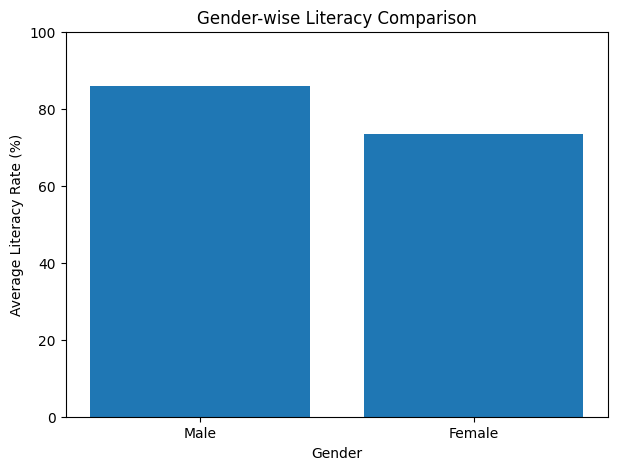

In [57]:
# ## Q5: Plot gender-wise literacy comparison (Bloom's Level: 5)

# ### Logic

# The 2011 rural and urban literacy rates for males and females
# are selected from the literacy dataset.
# The average literacy rate is calculated separately for males and females.
# A bar chart is then created using Matplotlib to compare the
# literacy rates of the two genders visually.

# ### Functions and Attributes Used

# mean()
# - Syntax: data.mean()
# - Calculates the arithmetic average.

# plt.figure()
# - Syntax: plt.figure(figsize=(width, height))
# - Creates a new figure for the graph.

# plt.bar()
# - Syntax: plt.bar(x, height)
# - Creates a bar chart using the given categories and values.

# plt.title()
# - Syntax: plt.title("Title")
# - Adds a title to the graph.

# plt.xlabel()
# - Syntax: plt.xlabel("Label")
# - Adds a label to the x-axis.

# plt.ylabel()
# - Syntax: plt.ylabel("Label")
# - Adds a label to the y-axis.

# plt.ylim()
# - Syntax: plt.ylim(lower, upper)
# - Sets the minimum and maximum values of the y-axis.

# plt.text()
# - Syntax: plt.text(x, y, "text")
# - Displays text at a specified position on the graph.

# plt.savefig()
# - Syntax: plt.savefig("filename.png")
# - Saves the generated graph as an image file.

# plt.show()
# - Syntax: plt.show()
# - Displays the graph.

# Q5: Plot gender-wise literacy comparison

# Calculate average male literacy rate
male_average = literacy[
    ["2011 - Rural - Male", "2011 - Urban - Male"]
].mean().mean()

# Calculate average female literacy rate
female_average = literacy[
    ["2011 - Rural - Female", "2011 - Urban - Female"]
].mean().mean()

# Create gender-wise DataFrame
gender_data = pd.DataFrame({
    "Gender": ["Male", "Female"],
    "Literacy Rate": [
        male_average,
        female_average
    ]
})

print("Q5: Gender-wise Literacy Comparison")
print(gender_data)

# Create graph using Matplotlib
plt.figure(figsize=(7, 5))

plt.bar(
    gender_data["Gender"],
    gender_data["Literacy Rate"]
)

plt.title("Gender-wise Literacy Comparison")
plt.xlabel("Gender")
plt.ylabel("Average Literacy Rate (%)")
plt.ylim(0, 100)

plt.savefig("/content/gender_literacy_comparison.png")

plt.show()

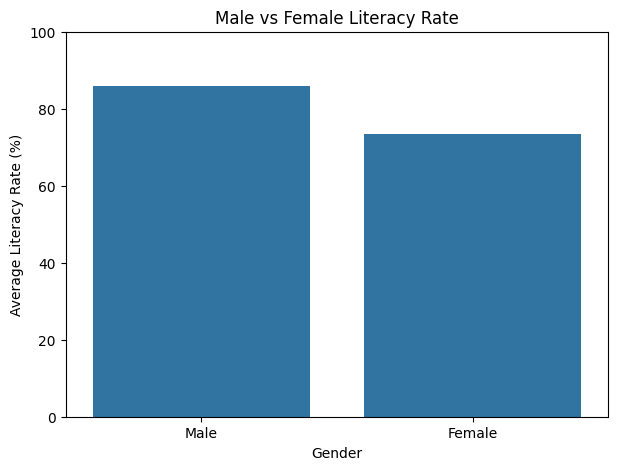

In [58]:
# Q5: Gender-wise literacy comparison using Seaborn

plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_data,
    x="Gender",
    y="Literacy Rate"
)

plt.title("Male vs Female Literacy Rate")
plt.xlabel("Gender")
plt.ylabel("Average Literacy Rate (%)")
plt.ylim(0, 100)

plt.savefig("/content/gender_literacy_seaborn.png")

plt.show()

In [59]:
# NumPy analysis

literacy_values = np.array([
    male_average,
    female_average
])

print("NumPy Analysis")

print(
    "Highest Gender Literacy Rate =",
    round(np.max(literacy_values), 2),
    "%"
)

print(
    "Lowest Gender Literacy Rate =",
    round(np.min(literacy_values), 2),
    "%"
)

print("\nAnalysis completed successfully.")

NumPy Analysis
Highest Gender Literacy Rate = 85.93 %
Lowest Gender Literacy Rate = 73.44 %

Analysis completed successfully.
